#**Código Python: Unidade 3 - Modelos de Regressão**

# **Passo 1: Configurar o ambiente**
###Instalando a Biblioteca para análise de Sobrevivência





In [ ]:
pip install lifelines

###Importando as funções

In [ ]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
from lifelines.plotting import add_at_risk_counts
import matplotlib.pyplot as plt

# **Passo 2: Código Python**

#**Exemplo: Modelo Cox**
##Cenário: Um estudo clínico hipotético realizado para avaliar a eficácia de um novo tratamento em pacientes diagnosticados câncer. O objetivo do estudo é identificar fatores que influenciam a sobrevivência dos pacientes, como idade, sexo e se eles receberam ou não o tratamento experimental

###Inserir dados

In [ ]:
# 1. Criação dos Dados Simulados
np.random.seed(42)
n = 100  # Número de pacientes

data = pd.DataFrame({
    'time': np.random.exponential(10, size=n).astype(int),  # Tempo de sobrevivência
    'event': np.random.choice([1, 0], size=n, p=[0.7, 0.3]),  # Evento (1=falha, 0=censurado)
    'age': np.random.randint(30, 80, size=n),  # Idade
    'sex': np.random.choice([0, 1], size=n),  # Sexo (0=feminino, 1=masculino)
    'treatment': np.random.choice([0, 1], size=n)  # Tratamento (0=controle, 1=tratado)
})
print(data)

    time  event  age  sex  treatment
0      4      1   53    1          1
1     30      1   40    0          0
2     13      1   78    0          0
3      9      1   37    0          1
4      1      0   65    1          1
..   ...    ...  ...  ...        ...
95     6      1   56    0          0
96     7      0   71    1          0
97     5      0   31    0          0
98     0      0   55    0          1
99     1      0   46    0          0

[100 rows x 5 columns]


###Número de falhas e censuras

In [ ]:
# Contar o número de censuras (event = 0)
num_censored = (data['event'] == 0).sum()

# Contar o número de eventos observados (event = 1)
num_events = (data['event'] == 1).sum()

# Exibir os resultados
print(f"Número de dados censurados: {num_censored}")
print(f"Número de mortes observados: {num_events}")

Número de dados censurados: 30
Número de mortes observados: 70


###Ajuste do Modelo Cox

In [ ]:
# 2. Ajuste do Modelo de Cox
cph = CoxPHFitter()
cph.fit(data, duration_col='time', event_col='event')
cph.print_summary()  # Mostra os coeficientes e estatísticas do modelo

<lifelines.CoxPHFitter: fitted with 100 total observations, 30 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 100
number of events observed = 70
   partial log-likelihood = -251.61
         time fit was run = 2024-12-30 15:03:38 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.00      1.00      0.01           -0.02            0.02                0.98                1.02
sex        0.19      1.21      0.25           -0.29            0.68                0.75                1.98
treatment  0.06      1.06      0.25           -0.43            0.54                0.65                1.72

           cmp to    z    p  -log2(p)
covariate                            
age          0.00 0.08 0.94      0.10
sex          0.00 0.78 0.44      1.19
treatment    0.00 0.23 0.82      0.29
---
Concordance = 0.53
Partial AIC = 509.21
log-likelihood ratio test = 0.68 on 3 df
-log2(p) of ll-ratio test = 0.19

Idade com efeito praticamente nulo e p=0.08 indicanão significativa.

Sexo masculino aumenta o tempo esperado (exp(coef)>1), porém não significativo.

Tratamento também aumenta o tempo esperado (exp(coef)>1), não significativo.

Log-likelihood ratio test p=0.19: o modelo com covariáveis não difere significativamente do modelo sem covariáveis (modelo nulo).

A concordância (C-index) = 0,53 indica que a capacidade do modelo classificar pacientes com maior e menor risco é baixa.

Valores do C-index:

1.0 = previsão perfeita (o modelo acerta todas as ordens).

0.5 = previsão aleatória (modelo não tem poder discriminativo, igual a jogar uma moeda).

< 0.5 = pior que o acaso (modelo está invertendo a ordem na maioria dos casos).

###Análise Gráfica dos Resíduos


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.4188)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3383)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6746)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5937)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5468)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5178)'>]]

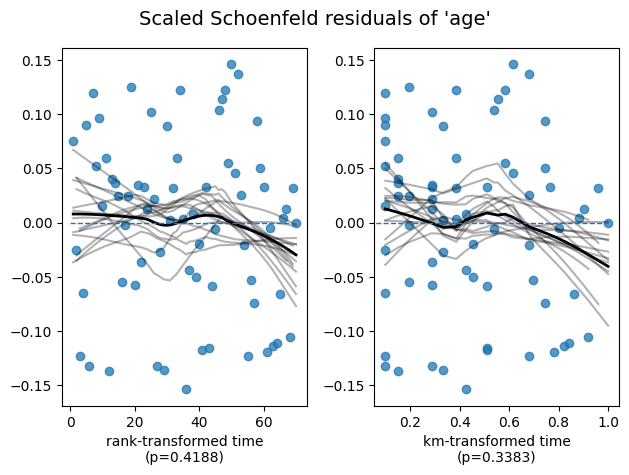

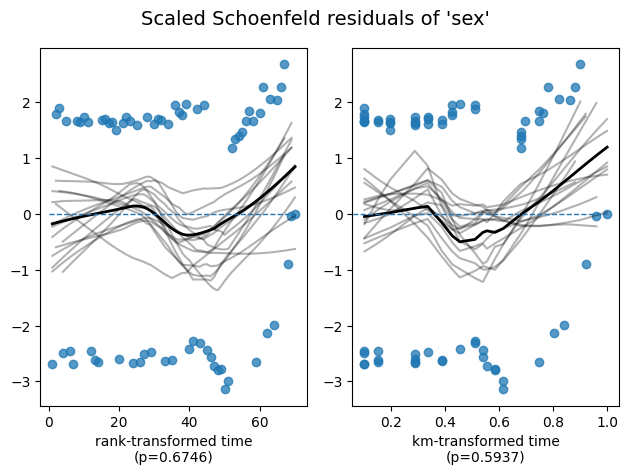

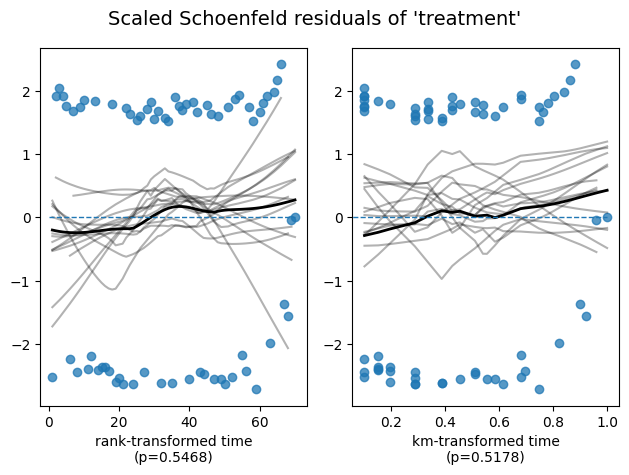

In [ ]:
# 3. Análise Gráfica de Resíduos
# Verificação da suposição de riscos proporcionais
cph.check_assumptions(data, show_plots=True)

    time  event  martingale
83   0.0  False   -0.112476
98   0.0  False   -0.091623
6    0.0   True    0.912622
10   0.0   True    0.888908
29   0.0   True    0.890276
..   ...    ...         ...
1   30.0   True   -1.068249
34  33.0  False   -2.578100
50  34.0  False   -2.094023
11  35.0   True   -1.731620
69  43.0   True   -2.709817

[100 rows x 3 columns]


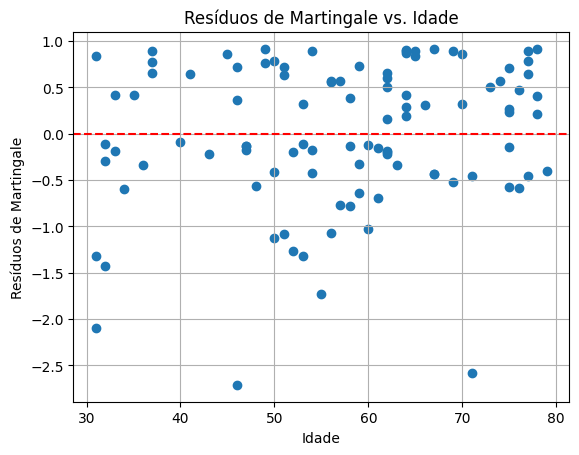

In [ ]:
# Cálculo dos resíduos de Martingale
#adequação das covariàveis
martingale_residuals = cph.compute_residuals(data, kind="martingale")
print(martingale_residuals)
# Visualização dos resíduos
plt.scatter(data['age'], martingale_residuals['martingale'])
plt.axhline(0, color='red', linestyle='--')
plt.title('Resíduos de Martingale vs. Idade')
plt.xlabel('Idade')
plt.ylabel('Resíduos de Martingale')
plt.grid(True)
plt.show()

###Estimando a Função de Sobrevivência S(t) pelo Modelo de Cox

###Gráfico da função de sobrevivência para comparar 2 pacientes com 40 anos do sexo masculino: paciente 1 - controle e paciente 2 - tratado

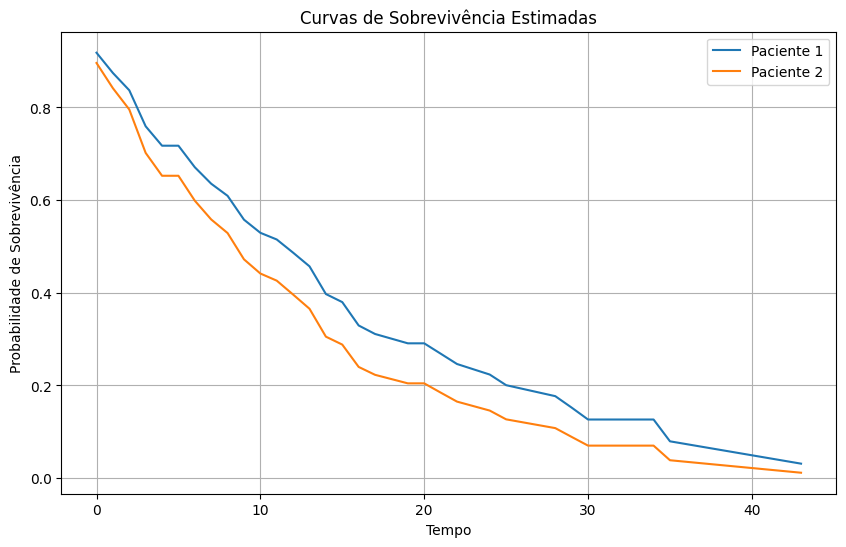

In [ ]:
# Predição de curvas de sobrevivência para diferentes perfis
new_patients = pd.DataFrame({
    'age': [40, 40],  # Idade
    'sex': [1, 1],    # Sexo
    'treatment': [0, 1]  # Tratamento
})

# Obter curvas de sobrevivência
survival_curves = cph.predict_survival_function(new_patients)

# Plotar curvas de sobrevivência
plt.figure(figsize=(10, 6))
for i, curve in enumerate(survival_curves.T.iterrows()):
    plt.plot(curve[1], label=f'Paciente {i+1}')
plt.title('Curvas de Sobrevivência Estimadas')
plt.xlabel('Tempo')
plt.ylabel('Probabilidade de Sobrevivência')
plt.legend()
plt.grid()
plt.show()

###Gráfico da função de sobrevivência para comparar 2 pacientes com 40 anos do sexo feminino: paciente 1 - controle e paciente 2 - tratado

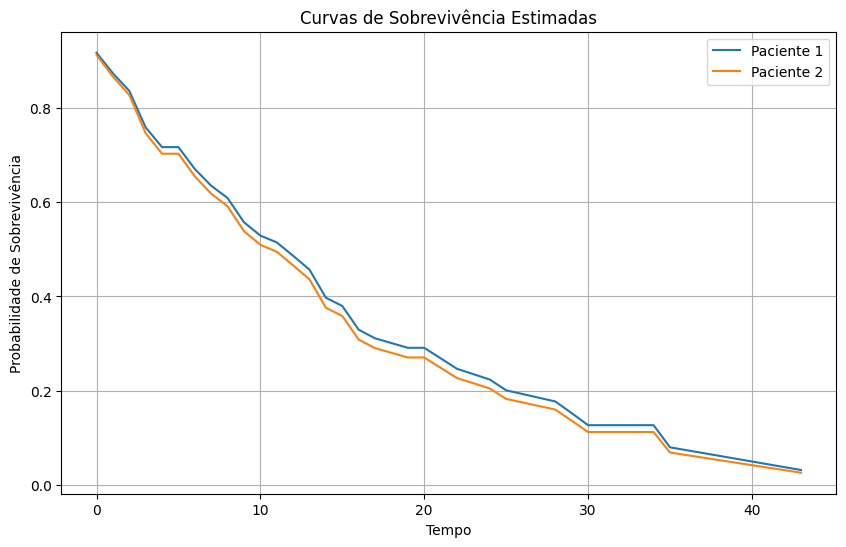

In [ ]:
# Predição de curvas de sobrevivência para diferentes perfis
new_patients = pd.DataFrame({
    'age': [40, 40],  # Idade
    'sex': [0, 0],    # Sexo
    'treatment': [0, 1]  # Tratamento
})

# Obter curvas de sobrevivência
survival_curves = cph.predict_survival_function(new_patients)

# Plotar curvas de sobrevivência
plt.figure(figsize=(10, 6))
for i, curve in enumerate(survival_curves.T.iterrows()):
    plt.plot(curve[1], label=f'Paciente {i+1}')
plt.title('Curvas de Sobrevivência Estimadas')
plt.xlabel('Tempo')
plt.ylabel('Probabilidade de Sobrevivência')
plt.legend()
plt.grid()
plt.show()

Gráfico da função de sobrevivência para comparar 2 pacientes com 40 anos do sexo feminino  e masculino: paciente 1 - feminino e controle e paciente 2 - masculino e tratado

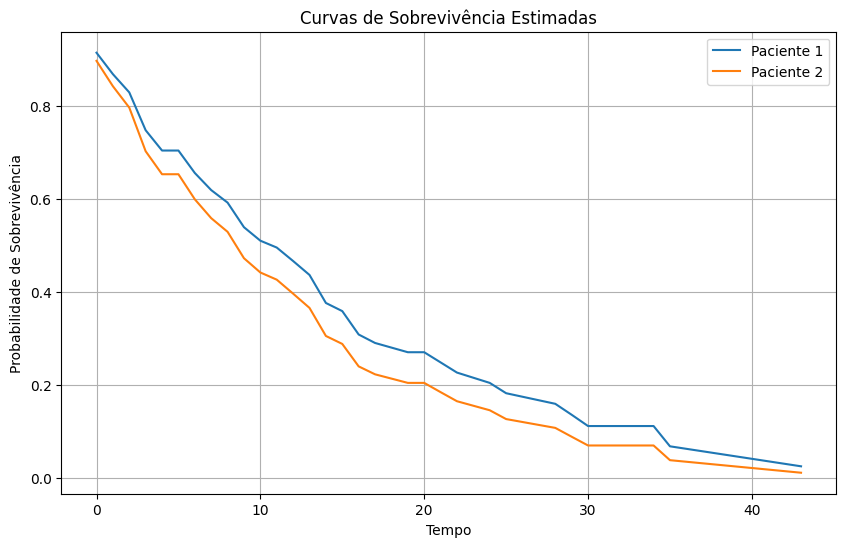

In [ ]:
# Predição de curvas de sobrevivência para diferentes perfis
new_patients = pd.DataFrame({
    'age': [40, 40],  # Idade
    'sex': [0, 1],    # Sexo
    'treatment': [0, 1]  # Tratamento
})

# Obter curvas de sobrevivência
survival_curves = cph.predict_survival_function(new_patients)

# Plotar curvas de sobrevivência
plt.figure(figsize=(10, 6))
for i, curve in enumerate(survival_curves.T.iterrows()):
    plt.plot(curve[1], label=f'Paciente {i+1}')
plt.title('Curvas de Sobrevivência Estimadas')
plt.xlabel('Tempo')
plt.ylabel('Probabilidade de Sobrevivência')
plt.legend()
plt.grid()
plt.show()

###Razão de risco para o tratamento no sexo masculino

In [ ]:
# 5. Razão de Risco
# Comparar dois pacientes:
# Paciente A: idade 40, sexo masculino, sem tratamento
# Paciente B: idade 40, sexo masculino, com tratamento

patient_A = pd.DataFrame({'age': [40], 'sex': [1], 'treatment': [0]})
patient_B = pd.DataFrame({'age': [40], 'sex': [1], 'treatment': [1]})

hazard_A = cph.predict_partial_hazard(patient_A).values[0]
hazard_B = cph.predict_partial_hazard(patient_B).values[0]
hazard_ratio = hazard_B / hazard_A

print(f"Razão de Risco (Paciente B / Paciente A): {hazard_ratio:.2f}")

Razão de Risco (Paciente B / Paciente A): 1.06


###Razão de Risco para o tratamento no sexo feminino

In [ ]:
# 5. Razão de Risco
# Comparar dois pacientes:
# Paciente A: idade 40, sexo feminino, sem tratamento
# Paciente B: idade 40, sexo feminino, com tratamento

patient_A = pd.DataFrame({'age': [40], 'sex': [0], 'treatment': [0]})
patient_B = pd.DataFrame({'age': [40], 'sex': [0], 'treatment': [1]})

hazard_A = cph.predict_partial_hazard(patient_A).values[0]
hazard_B = cph.predict_partial_hazard(patient_B).values[0]
hazard_ratio = hazard_B / hazard_A

print(f"Razão de Risco (Paciente B / Paciente A): {hazard_ratio:.2f}")

Razão de Risco (Paciente B / Paciente A): 1.06


###Gráfico da função de sobrevivência para cada tratamento pelo KM - Para uma análise Exploratória

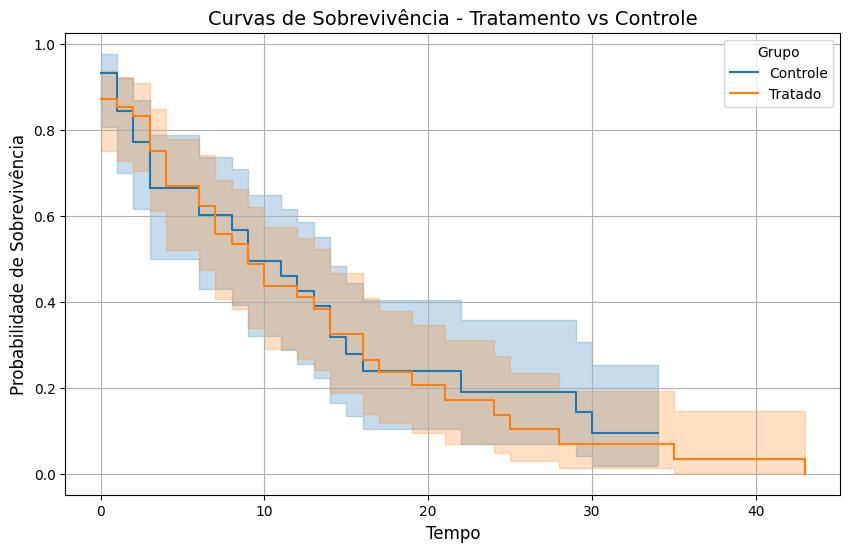

In [ ]:
# Cálculo das curvas de sobrevivência estratificadas pelo tratamento
from lifelines import CoxPHFitter, KaplanMeierFitter
kmf_control = KaplanMeierFitter()
kmf_treated = KaplanMeierFitter()
# Dados para cada grupo
data_control = data[data['treatment'] == 0]
data_treated = data[data['treatment'] == 1]
# Ajuste do Kaplan-Meier para controle
kmf_control.fit(durations=data_control['time'], event_observed=data_control['event'], label='Controle')

# Ajuste do Kaplan-Meier para tratados
kmf_treated.fit(durations=data_treated['time'], event_observed=data_treated['event'], label='Tratado')

# Plotagem das curvas de sobrevivência
plt.figure(figsize=(10, 6))
kmf_control.plot_survival_function(ci_show=True)
kmf_treated.plot_survival_function(ci_show=True)

plt.title('Curvas de Sobrevivência - Tratamento vs Controle', fontsize=14)
plt.xlabel('Tempo', fontsize=12)
plt.ylabel('Probabilidade de Sobrevivência', fontsize=12)
plt.legend(title='Grupo', fontsize=10)
plt.grid(True)
plt.show()

#**Exemplo 1: Modelo Taxa Acelerada**
##Cenário: Um estudo clínico hipotético realizado para avaliar a eficácia de um novo tratamento em pacientes diagnosticados câncer. O objetivo do estudo é identificar fatores que influenciam a sobrevivência dos pacientes, como idade, sexo e se eles receberam ou não o tratamento experimental

### Instalando a Biblioteca

In [ ]:
pip install lifelines

### Importar as funções

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter, LogLogisticAFTFitter, WeibullAFTFitter, LogNormalAFTFitter
from lifelines.statistics import proportional_hazard_test

###Inserindo os dados

In [ ]:
# 1. Criação dos Dados Simulados
np.random.seed(42)
n = 100  # Número de pacientes

data = pd.DataFrame({
    'time': np.random.exponential(10, size=n).astype(int)+ 1,  # Tempo de sobrevivência
    'event': np.random.choice([1, 0], size=n, p=[0.7, 0.3]),  # Evento (1=falha, 0=censurado)
    'age': np.random.randint(30, 80, size=n),  # Idade
    'sex': np.random.choice([0, 1], size=n),  # Sexo (0=feminino, 1=masculino)
    'treatment': np.random.choice([0, 1], size=n)  # Tratamento (0=controle, 1=tratado)
})
print(data)

    time  event  age  sex  treatment
0      5      1   53    1          1
1     31      1   40    0          0
2     14      1   78    0          0
3     10      1   37    0          1
4      2      0   65    1          1
..   ...    ...  ...  ...        ...
95     7      1   56    0          0
96     8      0   71    1          0
97     6      0   31    0          0
98     1      0   55    0          1
99     2      0   46    0          0

[100 rows x 5 columns]


#AFT-Weibull

In [ ]:
from lifelines import WeibullAFTFitter
# Ajustar um modelo AFT Weibull
aft_Weibull = WeibullAFTFitter()
aft_Weibull.fit(data, duration_col='time', event_col='event')

# Resumo do modelo
print("\nResumo do modelo AFT (Weibull):")
aft_Weibull.print_summary()


Resumo do modelo AFT (Weibull):


<lifelines.WeibullAFTFitter: fitted with 100 total observations, 30 right-censored observations>
             duration col = 'time'
                event col = 'event'
   number of observations = 100
number of events observed = 70
           log-likelihood = -252.67
         time fit was run = 2025-08-25 17:35:13 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ age       -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
        sex       -0.17      0.84      0.21           -0.59            0.25                0.55                1.28
        treatment -0.07      0.93      0.22           -0.49            0.35                0.61                1.42
        Intercept  2.78     16.07      0.48            1.83            3.73                6.23               41.48
rho_    Intercept  0.12      1.13      0.09           -0.06            0.30                0.94                1.35

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ age          0.00 -0.02   0.99      0.02
        sex          0.00 -0.80   0.42      1.24
        treatment    0.00 -0.34   0.73      0.44
        Intercept    0.00  5.74 <0.005     26.66
rho_    Intercept    0.00  1.32   0.19      2.42
---
Concordance = 0.53
AIC = 515.34
log-likelihood ratio test = 0.75 on 3 df
-log2(p) of ll-ratio test = 0.21

Idade com efeito praticamente nulo e com p=0.99 coef não significativo.

Sexo masculino reduz tempo esperado (exp(coef)<1), porém não significativo.

Tratamento também reduz o tempo esperado (exp(coef)<1), não significativo.

Log-likelihood ratio test p=0.21: o modelo com covariáveis não difere significativamente do modelo sem covariáveis (modelo nulo).

A concordância (C-index) = 0,53 indica que a capacidade do modelo classificar pacientes com maior e menor risco é baixa.

Valores do C-index:

1.0 = previsão perfeita (o modelo acerta todas as ordens).

0.5 = previsão aleatória (modelo não tem poder discriminativo, igual a jogar uma moeda).

< 0.5 = pior que o acaso (modelo está invertendo a ordem na maioria dos casos).

#Análise de Resíduos

In [ ]:
#resíduo log-temporal
data['log_time_observado'] = np.log(data['time'])
data['log_time_ajustado'] = np.log(aft_Weibull.predict_median(data))
data['residuo'] = data['log_time_observado'] - data['log_time_ajustado']

###Resíduos de Cox-Snell

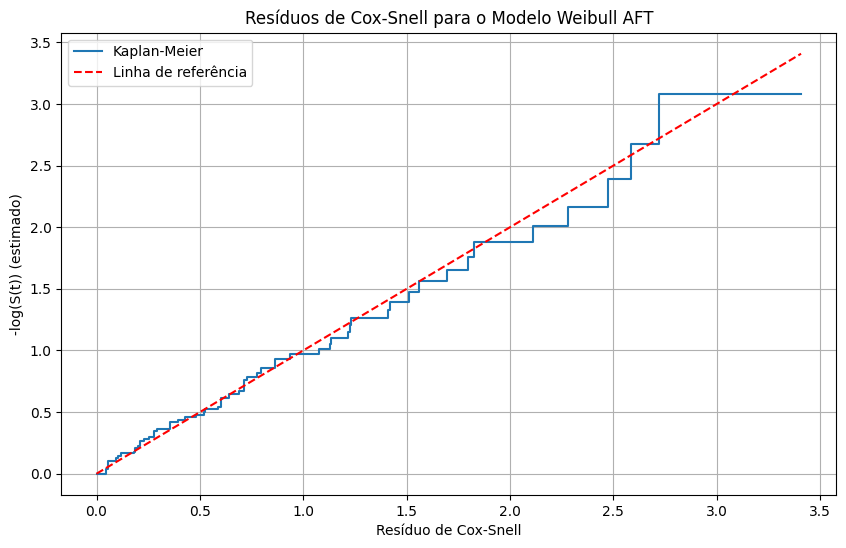

In [ ]:
# Calcular a função de risco cumulativo predita para cada indivíduo no tempo observado
data['cox_snell_residuals'] = [
    aft_Weibull.predict_cumulative_hazard(data.iloc[[i]]).loc[data['time'].iloc[i]].values[0]
    for i in range(len(data))
]

# Ajustar um estimador Kaplan-Meier aos resíduos
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(data['cox_snell_residuals'], event_observed=data['event'])

# Plotar os resíduos de Cox-Snell
plt.figure(figsize=(10, 6))
plt.step(kmf.survival_function_.index, -np.log(kmf.survival_function_['KM_estimate']), where="post", label="Kaplan-Meier")
plt.plot([0, max(data['cox_snell_residuals'])], [0, max(data['cox_snell_residuals'])], linestyle='--', color='red', label="Linha de referência")
plt.title("Resíduos de Cox-Snell para o Modelo Weibull AFT")
plt.xlabel("Resíduo de Cox-Snell")
plt.ylabel("-log(S(t)) (estimado)")
plt.legend()
plt.grid()
plt.show()

Indica um bom ajuste do modelo aos dados

###Resíduos Deviance

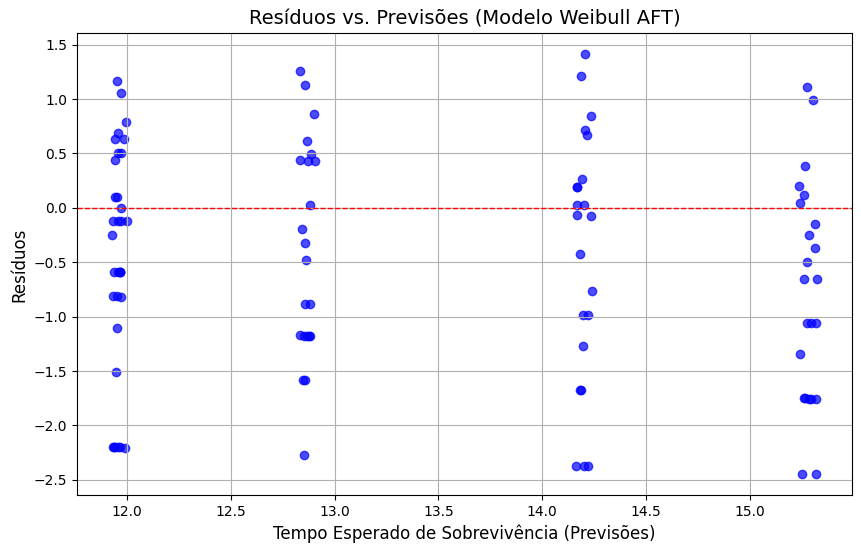

In [ ]:
# Resíduos vs. Previsões
previsoes = aft_Weibull.predict_expectation(data)

plt.figure(figsize=(10, 6))
plt.scatter(previsoes, data['residuo'], alpha=0.7, color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Resíduos vs. Previsões (Modelo Weibull AFT)", fontsize=14)
plt.xlabel("Tempo Esperado de Sobrevivência (Previsões)", fontsize=12)
plt.ylabel("Resíduos", fontsize=12)
plt.grid(True)
plt.show()


Concentração dos tempos previstos em poucos valores (12, 13, 14, 15) indicando os coeficientes são poucos significativos o que limita o poder explicativo do modelo

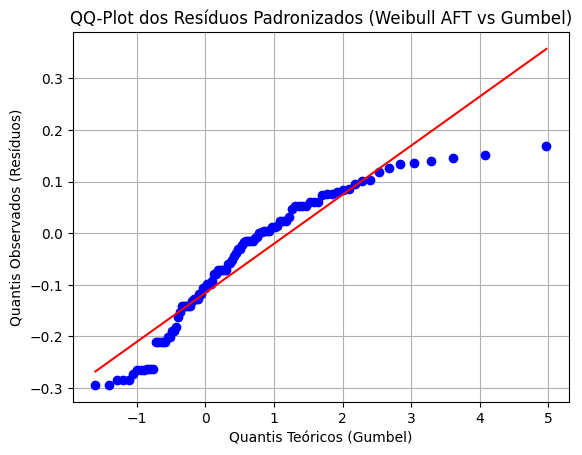

In [ ]:
# Pegar o parâmetro rho_ do modelo
rho = 0.12
sigma = 1 / rho

# Padronizar resíduos
residuos_padronizados = data['residuo'] / sigma

# QQ-plot
stats.probplot(residuos_padronizados, dist="gumbel_r", plot=plt)
plt.title("QQ-Plot dos Resíduos Padronizados (Weibull AFT vs Gumbel)")
plt.xlabel("Quantis Teóricos (Gumbel)")
plt.ylabel("Quantis Observados (Resíduos)")
plt.grid(True)
plt.show()

O desvio nas caudas sugere que os resíduos podem não seguir perfeitamente a distribuição Gumbel nas regiões extremas, apresentando alguma assimetria ou outliers

O modelo está razoavelmente adequado para capturar o comportamento geral dos resíduos, mas pode haver alguma limitação para capturar os extremos

###Curva de Sobrevivencia Kaplan-Meie vs Modelo Ajustado Weibul_AFT

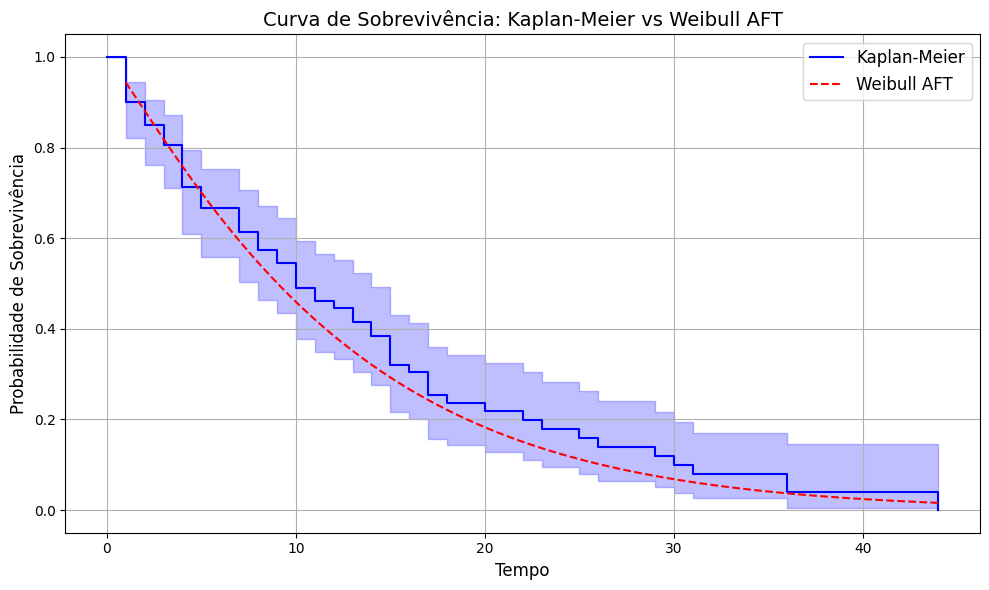

In [ ]:
# Curva de Sobrevivência (Kaplan-Meier vs Modelo Weibull)
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

# Estimativa Kaplan-Meier
kmf.fit(data['time'], event_observed=data['event'], label='Kaplan-Meier')
kmf.plot_survival_function(ci_show=True, ax=plt.gca(), color='blue')


# Previsão do Modelo Weibull
times = np.linspace(1, data['time'].max(), 100)
survival_curve = aft_Weibull.predict_survival_function(data.iloc[0:1], times=times)
plt.plot(times, survival_curve.values.flatten(), label='Weibull AFT', color='red', linestyle='--')

# Configurações do Gráfico
plt.title("Curva de Sobrevivência: Kaplan-Meier vs Weibull AFT", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Probabilidade de Sobrevivência", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

O gráfico mostra que o modelo Weibull AFT apresenta um bom ajuste à curva de sobrevivência empírica, principalmente nos tempos iniciais e intermediários.

Apesar de uma leve subestimação da probabilidade de sobrevivência em tempos mais longos, o modelo permanece dentro da faixa de confiança da Kaplan-Meier na maior parte do tempo.

Isso reforça sua adequação para modelar os dados de sobrevivência.

###AIC e BIC do modelo AFT_Weibull

In [ ]:
print(aft_Weibull.AIC_)
print (aft_Weibull.BIC_)

515.3402400083787
514.550580380355


#AFT-Log-Normal

In [ ]:
from lifelines import KaplanMeierFitter, CoxPHFitter, LogNormalAFTFitter
# Ajustar um modelo AFT Weibull
aft_LogNormal = LogNormalAFTFitter()
aft_LogNormal.fit(data, duration_col='time', event_col='event')

# Resumo do modelo
print("\nResumo do modelo AFT (Weibull):")
aft_LogNormal.print_summary()


Resumo do modelo AFT (Weibull):


<lifelines.LogNormalAFTFitter: fitted with 100 total observations, 30 right-censored observations>
             duration col = 'time'
                event col = 'event'
   number of observations = 100
number of events observed = 70
           log-likelihood = -253.74
         time fit was run = 2025-08-25 17:43:00 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                  
mu_    age       -0.00      1.00      0.01           -0.02            0.01                0.98                1.02
       sex       -0.13      0.88      0.25           -0.62            0.36                0.54                1.44
       treatment -0.02      0.98      0.25           -0.52            0.47                0.60                1.60
       Intercept  2.39     10.97      0.54            1.35            3.44                3.84               31.31
sigma_ Intercept  0.13      1.14      0.08           -0.04            0.29                0.96                1.34

                  cmp to     z      p  -log2(p)
param  covariate                               
mu_    age          0.00 -0.30   0.77      0.38
       sex          0.00 -0.52   0.61      0.72
       treatment    0.00 -0.10   0.92      0.12
       Intercept    0.00  4.47 <0.005     16.99
sigma_ Intercept    0.00  1.50   0.13      2.92
---
Concordance = 0.53
AIC = 517.47
log-likelihood ratio test = 0.42 on 3 df
-log2(p) of ll-ratio test = 0.09

Os coeficientes indicam o efeito das variáveis explicativas sobre o tempo esperado.

exp(coef) próximo de 1 significa efeito pequeno ou nulo

Nenhuma variável além do intercepto apresentou efeito estatisticamente significativo (p < 0.05).

A concordância (C-index) = 0,53 é igual ao modelo Weibull e indica que a capacidade do modelo classificar pacientes com maior e menor risco é baixa.

Valores do C-index:

1.0 = previsão perfeita (o modelo acerta todas as ordens).

0.5 = previsão aleatória (modelo não tem poder discriminativo, igual a jogar uma moeda).

< 0.5 = pior que o acaso (modelo está invertendo a ordem na maioria dos casos).

###Análise dos Resíduos

In [ ]:
#resíduo log-temporal
data['log_time_observado'] = np.log(data['time'])
data['log_time_ajustado'] = np.log(aft_LogNormal.predict_median(data))
data['residuo_log'] = data['log_time_observado'] - data['log_time_ajustado']

###Resíduos Cox-Snell

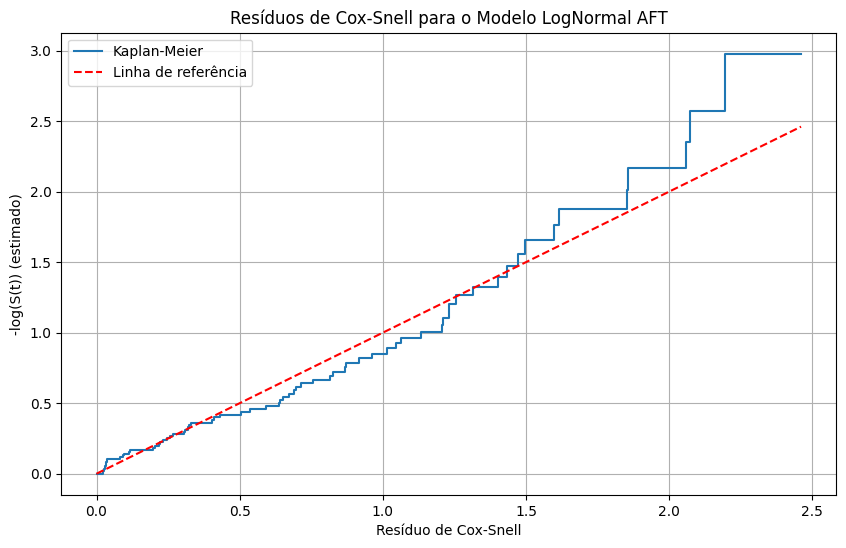

In [ ]:
# Calcular a função de risco cumulativo predita para cada indivíduo no tempo observado
data['cox_snell_residuals'] = [
   aft_LogNormal.predict_cumulative_hazard(data.iloc[[i]]).loc[data['time'].iloc[i]].values[0]
    for i in range(len(data))
]

# Ajustar um estimador Kaplan-Meier aos resíduos
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(data['cox_snell_residuals'], event_observed=data['event'])

# Plotar os resíduos de Cox-Snell
plt.figure(figsize=(10, 6))
plt.step(kmf.survival_function_.index, -np.log(kmf.survival_function_['KM_estimate']), where="post", label="Kaplan-Meier")
plt.plot([0, max(data['cox_snell_residuals'])], [0, max(data['cox_snell_residuals'])], linestyle='--', color='red', label="Linha de referência")
plt.title("Resíduos de Cox-Snell para o Modelo LogNormal AFT")
plt.xlabel("Resíduo de Cox-Snell")
plt.ylabel("-log(S(t)) (estimado)")
plt.legend()
plt.grid()
plt.show()

A curva se afasta da linha de identidade → pode haver superestimação ou subestimação do risco cumulativo para indivíduos com tempos de sobrevivência mais altos (ou eventos tardios).

Pode sugerir que o modelo não está representando bem a cauda da distribuição.

###Resíduos Deviance

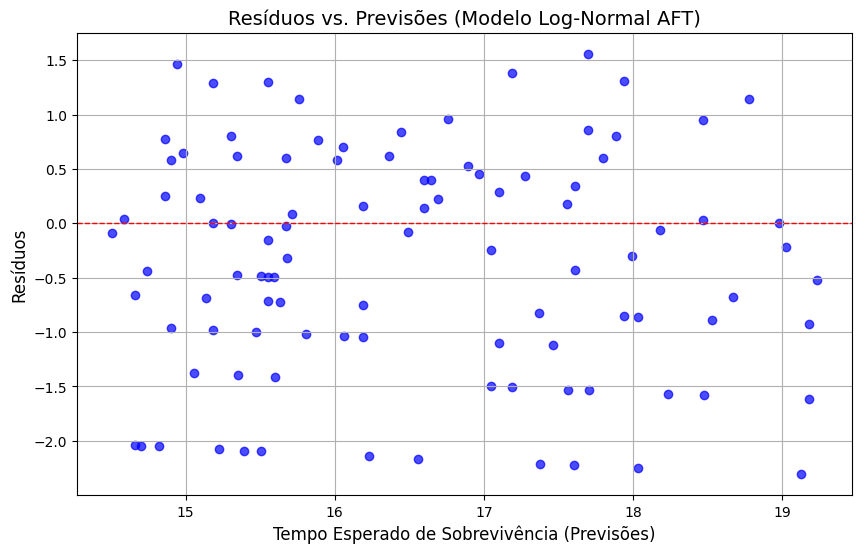

In [ ]:
# Resíduos vs. Previsões
previsoes = aft_LogNormal.predict_expectation(data)

plt.figure(figsize=(10, 6))
plt.scatter(previsoes, data['residuo_log'], alpha=0.7, color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Resíduos vs. Previsões (Modelo Log-Normal AFT)", fontsize=14)
plt.xlabel("Tempo Esperado de Sobrevivência (Previsões)", fontsize=12)
plt.ylabel("Resíduos", fontsize=12)
plt.grid(True)
plt.show()

A análise do resíduo deviance foi menos sensível a não significância dos parâmetros

##QQ-Plot dos resíduos

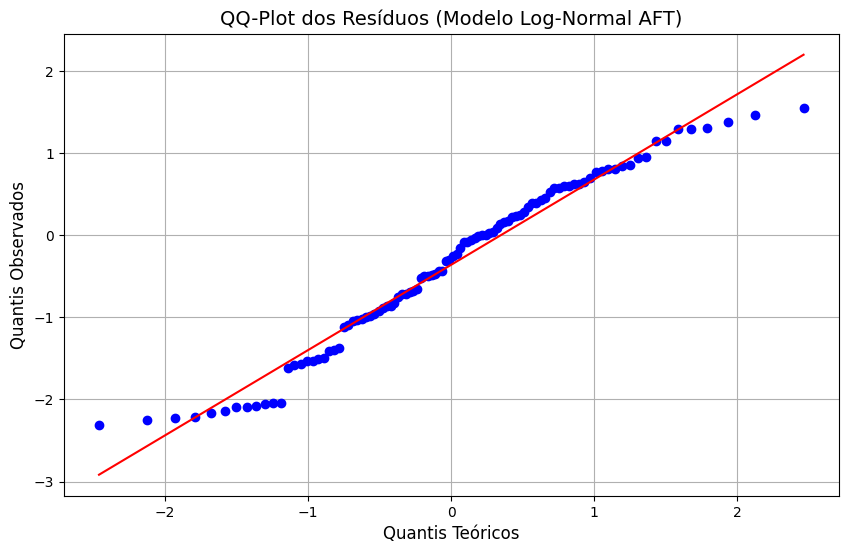

In [ ]:
# QQ-Plot dos Resíduos
import scipy.stats as stats

plt.figure(figsize=(10, 6))
stats.probplot(data['residuo_log'], dist="norm", plot=plt)
plt.title("QQ-Plot dos Resíduos (Modelo Log-Normal AFT)", fontsize=14)
plt.xlabel("Quantis Teóricos", fontsize=12)
plt.ylabel("Quantis Observados", fontsize=12)
plt.grid(True)
plt.show()

Nas extremidades, há um desvio um pouco maior, mas não muito expressivo, indicando que os resíduos seguem bem a distribuição log-normal.



###Curva de sobrevivência Kaplan-Meier vs AFT-Log-normal

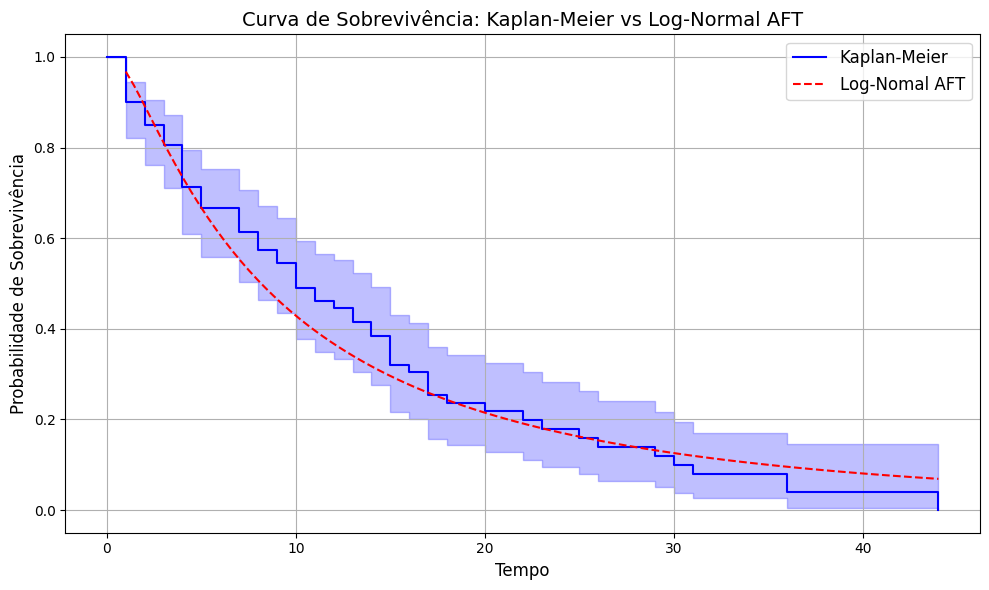

In [ ]:
# Curva de Sobrevivência (Kaplan-Meier vs Modelo Weibull)
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

# Estimativa Kaplan-Meier
kmf.fit(data['time'], event_observed=data['event'], label='Kaplan-Meier')
kmf.plot_survival_function(ci_show=True, ax=plt.gca(), color='blue')


# Previsão do Modelo Weibull
times = np.linspace(1, data['time'].max(), 100)
survival_curve = aft_LogNormal.predict_survival_function(data.iloc[0:1], times=times)
plt.plot(times, survival_curve.values.flatten(), label='Log-Nomal AFT', color='red', linestyle='--')

# Configurações do Gráfico
plt.title("Curva de Sobrevivência: Kaplan-Meier vs Log-Normal AFT", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Probabilidade de Sobrevivência", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

O modelo Log-Normal AFT apresenta um bom ajuste para os tempos iniciais, mas tende a subestimar a probabilidade de sobrevivência nos tempos médios e longos, em comparação com a curva de Kaplan-Meier.

Embora o ajuste ainda esteja dentro do intervalo de confiança empírico, essa discrepância sugere que o modelo pode ser mais conservador nas estimativas de longo prazo.

###AIC e BIC log_normal

In [ ]:
print(aft_LogNormal.AIC_)
print (aft_LogNormal.BIC_)

517.4733597682896
516.6837001402658


# AFT-Log Logístico

In [ ]:
from lifelines import KaplanMeierFitter, CoxPHFitter, LogLogisticAFTFitter
aft_LogListico = LogLogisticAFTFitter()
aft_LogListico.fit(data, duration_col="time", event_col="event")
print("\nResumo do modelo AFT (Log-logístico):")
aft_LogListico.print_summary()


Resumo do modelo AFT (Log-logístico):


<lifelines.LogLogisticAFTFitter: fitted with 100 total observations, 30 right-censored observations>
             duration col = 'time'
                event col = 'event'
   number of observations = 100
number of events observed = 70
           log-likelihood = -255.00
         time fit was run = 2025-08-25 17:46:46 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                  
alpha_ age       -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
       sex       -0.15      0.86      0.25           -0.65            0.35                0.52                1.42
       treatment  0.04      1.04      0.26           -0.47            0.54                0.63                1.72
       Intercept  2.47     11.88      0.55            1.40            3.55                4.05               34.86
beta_  Intercept  0.41      1.51      0.10            0.22            0.60                1.25                1.82

                  cmp to     z      p  -log2(p)
param  covariate                               
alpha_ age          0.00 -0.39   0.69      0.53
       sex          0.00 -0.59   0.55      0.85
       treatment    0.00  0.14   0.89      0.17
       Intercept    0.00  4.51 <0.005     17.21
beta_  Intercept    0.00  4.27 <0.005     15.63
---
Concordance = 0.54
AIC = 520.00
log-likelihood ratio test = 0.51 on 3 df
-log2(p) of ll-ratio test = 0.12

Assim como no modelo Weibull e LogNormal, as covariáveis não apresentaram efeito estatisticamente significativo.

O intercepto é altamente significativo.

A concordância (C-index) é levemente melhor que o modelo LogNormal (0,53), mas ainda baixa. C-index (índice de concordância), é uma medida que avalia a capacidade do modelo de prever corretamente a ordem dos tempos de sobrevivência entre pares de indivíduos, ou seja, classificar pacientes com maior ou menor risco.

Valores do C-index:

1.0 = previsão perfeita (o modelo acerta todas as ordens).

0.5 = previsão aleatória (modelo não tem poder discriminativo, igual a jogar uma moeda).

< 0.5 = pior que o acaso (modelo está invertendo a ordem na maioria dos casos).

O AIC é um pouco maior, sugerindo que o modelo LogNormal pode ser ligeiramente preferível em termos de ajuste.

##Análise de Resíduos

In [ ]:
#resíduo log-temporal
data['log_time_observado'] = np.log(data['time'])
data['log_time_ajustado'] = np.log(aft_LogNormal.predict_median(data))
data['residuo_logl'] = data['log_time_observado'] - data['log_time_ajustado']

###Resíduos de cox-snell

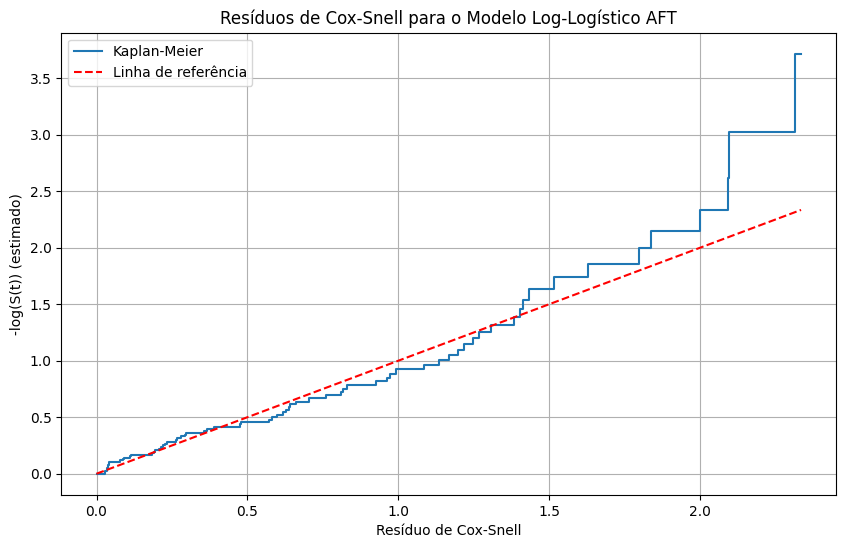

In [ ]:
# Calcular a função de risco cumulativo predita para cada indivíduo no tempo observado
data['cox_snell_residuals'] = [
   aft_LogListico.predict_cumulative_hazard(data.iloc[[i]]).loc[data['time'].iloc[i]].values[0]
    for i in range(len(data))
]

# Ajustar um estimador Kaplan-Meier aos resíduos
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(data['cox_snell_residuals'], event_observed=data['event'])

# Plotar os resíduos de Cox-Snell
plt.figure(figsize=(10, 6))
plt.step(kmf.survival_function_.index, -np.log(kmf.survival_function_['KM_estimate']), where="post", label="Kaplan-Meier")
plt.plot([0, max(data['cox_snell_residuals'])], [0, max(data['cox_snell_residuals'])], linestyle='--', color='red', label="Linha de referência")
plt.title("Resíduos de Cox-Snell para o Modelo Log-Logístico AFT")
plt.xlabel("Resíduo de Cox-Snell")
plt.ylabel("-log(S(t)) (estimado)")
plt.legend()
plt.grid()
plt.show()

O modelo LogLogístico AFT tem um ajuste razoável nos dados, mas pode ser melhorado, especialmente para valores médios e maiores do tempo residual.

###Resíduos Deviance

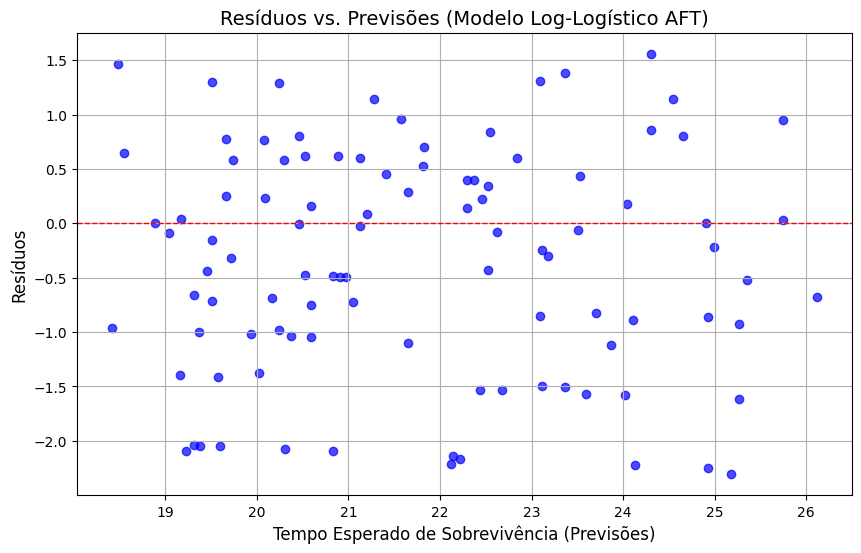

In [ ]:
# Resíduos vs. Previsões
previsoes =  aft_LogListico.predict_expectation(data)

plt.figure(figsize=(10, 6))
plt.scatter(previsoes, data['residuo_logl'], alpha=0.7, color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Resíduos vs. Previsões (Modelo Log-Logístico AFT)", fontsize=14)
plt.xlabel("Tempo Esperado de Sobrevivência (Previsões)", fontsize=12)
plt.ylabel("Resíduos", fontsize=12)
plt.grid(True)
plt.show()

Distribuição aproximadamente centrada em torno de zero (linha vermelha): Isso sugere ausência de viés sistemático.


###QQplot do modelo Log-lo´gistico

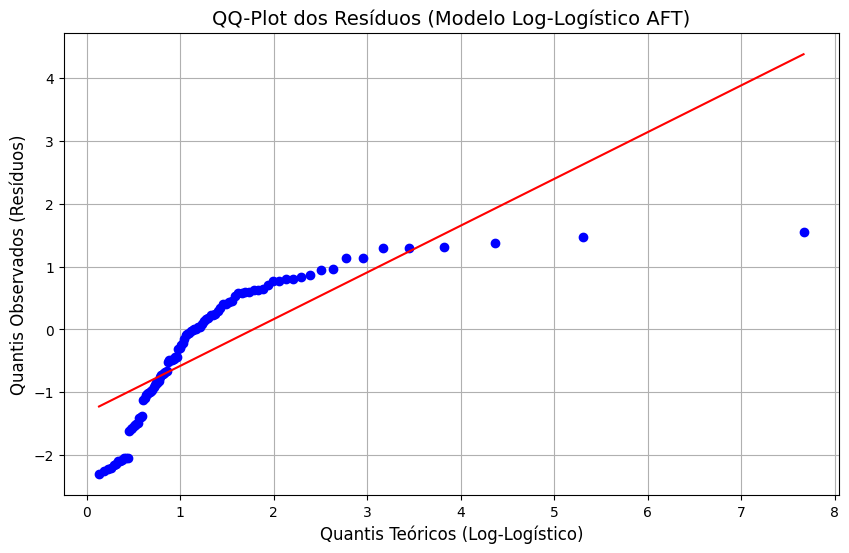

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Parâmetro de forma da distribuição log-logística (c = 1 / beta)
c = 1 / 0.41  # aproximadamente 2.44

plt.figure(figsize=(10, 6))
# Usando 'fisk' que é a distribuição log-logística no scipy
stats.probplot( data['residuo_logl'], dist="fisk",sparams=(c,), plot=plt)
plt.title("QQ-Plot dos Resíduos (Modelo Log-Logístico AFT)", fontsize=14)
plt.xlabel("Quantis Teóricos (Log-Logístico)", fontsize=12)
plt.ylabel("Quantis Observados (Resíduos)", fontsize=12)
plt.grid(True)
plt.show()


O gráfico sugere que o modelo log-logístico não se ajusta perfeitamente aos dados.

Ele parece razoável no centro da distribuição, mas falha nas caudas — especialmente para grandes valores de tempo de sobrevivência.

###Curva de sobrevivência por Kaplan-Meier vesus AFT Log-Logístico

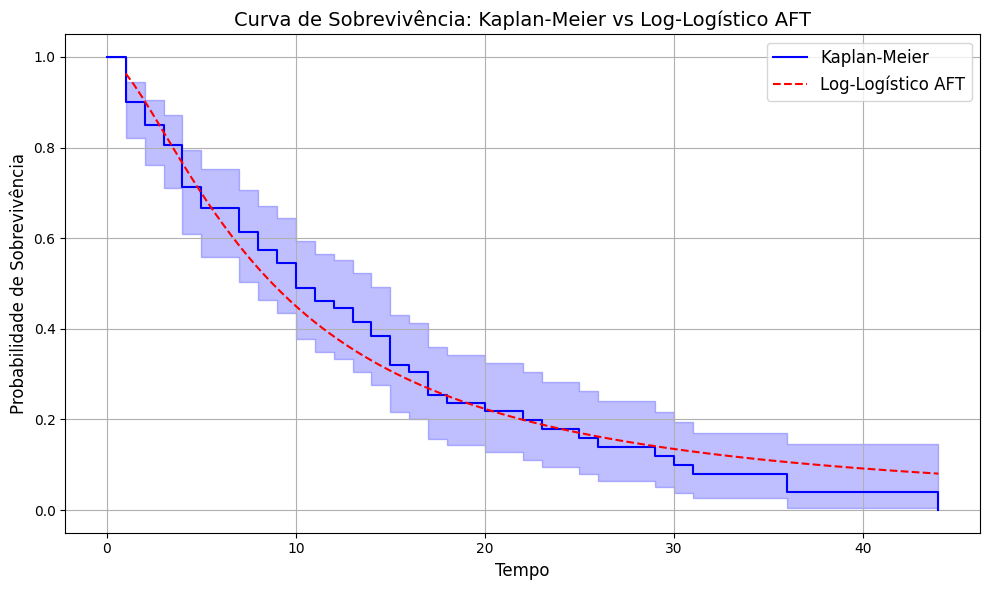

In [ ]:
# Curva de Sobrevivência (Kaplan-Meier vs Modelo Weibull)
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

# Estimativa Kaplan-Meier
kmf.fit(data['time'], event_observed=data['event'], label='Kaplan-Meier')
kmf.plot_survival_function(ci_show=True, ax=plt.gca(), color='blue')


# Previsão do Modelo Weibull
times = np.linspace(1, data['time'].max(), 100)
survival_curve = aft_LogListico.predict_survival_function(data.iloc[0:1], times=times)
plt.plot(times, survival_curve.values.flatten(), label='Log-Logístico AFT', color='red', linestyle='--')

# Configurações do Gráfico
plt.title("Curva de Sobrevivência: Kaplan-Meier vs Log-Logístico AFT", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Probabilidade de Sobrevivência", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

O modelo Log-Logístico AFT não apresentou um excelente ajuste em todos os períodos de tempo, com destaque para o médio e longo prazo, onde ele se sai  um pouco pior do que o Log-Normal.

Mas permanece dentro da faixa de confiança da curva empírica, oferecendo uma modelagem confiável da sobrevivência

###AIC e BIC modelo Log-Logístico

In [ ]:
print(aft_LogListico.AIC_)
print (aft_LogListico.BIC_)


520.0008555658573
519.2111959378334


#**Exemplo 2: Modelo Taxa Acelerada**
##Cenário: O cenário dos dados simulados está no contexto médico e representa um estudo de sobrevivência para avaliar o tempo de vida de pacientes após o diagnóstico de insuficiência cardíaca, considerando diferentes características demográficas e intervenções terapêuticas.
##Objetivo: Investigar os fatores que influenciam o tempo de sobrevivência de pacientes diagnosticados com insuficiência cardíaca.
#Descrição: Este estudo acompanha 300 pacientes diagnosticados com a mesma condição médica grave. Os pacientes foram alocados aleatoriamente em dois grupos: Tratamento padrão e Tratamento experimental.

###Instalando a Biblioteca para análise de Sobrevivência

In [ ]:
pip install lifelines

###Importar as funções

In [ ]:
import pandas as pd
import numpy as np
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, KaplanMeierFitter
from lifelines.datasets import load_rossi
import matplotlib.pyplot as plt
import scipy.stats as stats


###Carregar  os dados

In [ ]:
# Fixar semente para reprodutibilidade
np.random.seed(42)

# Criar dados sintéticos
n = 300  # Número de pacientes
age = np.random.uniform(30, 80, n)  # Idade dos pacientes (30-80 anos)
sex = np.random.choice(['Male', 'Female'], size=n)  # Sexo
treatment = np.random.choice(['Standard', 'Experimental'], size=n)  # Tipo de tratamento

# Mapear variáveis categóricas para numéricas
sex_numeric = (sex == 'Male').astype(int)  # 1 para Male, 0 para Female
treatment_numeric = (treatment == 'Experimental').astype(int)  # 1 para Experimental, 0 para Standard

# Gerar tempos de sobrevivência simulados (em meses)
baseline_hazard = 0.02
survival_time = (-np.log(np.random.uniform(0, 1, n)) /
                 (baseline_hazard * np.exp(0.03 * age - 0.5 * treatment_numeric + 0.2 * sex_numeric)))
survival_time = np.round(survival_time, 2)

# Gerar censura (evento observado ou não)
censoring = np.random.uniform(0.8, 1.5, n) * survival_time
event_observed = (survival_time <= censoring).astype(int)  # 1 para falha, 0 para censurado
observed_time = np.minimum(survival_time, censoring)

# Construir DataFrame
data = pd.DataFrame({
    'age': age,
    'sex': sex_numeric,         # Usando valores numéricos
    'treatment': treatment_numeric,  # Usando valores numéricos
    'time': observed_time,
    'event': event_observed
})

# Visualizar os primeiros dados
print(data.head())

         age  sex  treatment       time  event
0  48.727006    1          0  15.960384      0
1  77.535715    0          1   8.423111      0
2  66.599697    0          1  17.946813      0
3  59.932924    0          0  20.060000      1
4  37.800932    1          0  27.860000      1


#Numeros de morte e censuras

In [ ]:
# Contar o número de censuras (event = 0)
num_censored = (data['event'] == 0).sum()

# Contar o número de eventos observados (event = 1)
num_events = (data['event'] == 1).sum()

# Exibir os resultados
print(f"Número de dados censurados: {num_censored}")
print(f"Número de mortes observados: {num_events}")

Número de dados censurados: 86
Número de mortes observados: 214


#Ajuste do modelo Taxa Acelerada Weibull

In [ ]:
# Ajustar um modelo AFT Weibull
aft_model = WeibullAFTFitter()
aft_model.fit(data, duration_col='time', event_col='event')

# Resumo do modelo
aft_model.print_summary()


<lifelines.WeibullAFTFitter: fitted with 300 total observations, 86 right-censored observations>
             duration col = 'time'
                event col = 'event'
   number of observations = 300
number of events observed = 214
           log-likelihood = -802.80
         time fit was run = 2025-08-25 18:32:06 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ age       -0.03      0.97      0.00           -0.04           -0.02                0.96                0.98
        sex       -0.12      0.89      0.12           -0.36            0.12                0.70                1.13
        treatment  0.55      1.74      0.12            0.31            0.79                1.37                2.21
        Intercept  4.17     64.87      0.25            3.68            4.67               39.56              106.39
rho_    Intercept  0.11      1.11      0.05           -0.00            0.21                1.00                1.23

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ age          0.00 -7.05 <0.005     39.03
        sex          0.00 -0.97   0.33      1.58
        treatment    0.00  4.48 <0.005     17.05
        Intercept    0.00 16.53 <0.005    201.51
rho_    Intercept    0.00  1.96   0.05      4.31
---
Concordance = 0.63
AIC = 1615.59
log-likelihood ratio test = 61.48 on 3 df
-log2(p) of ll-ratio test = 41.68

###Análise dos Resíduos

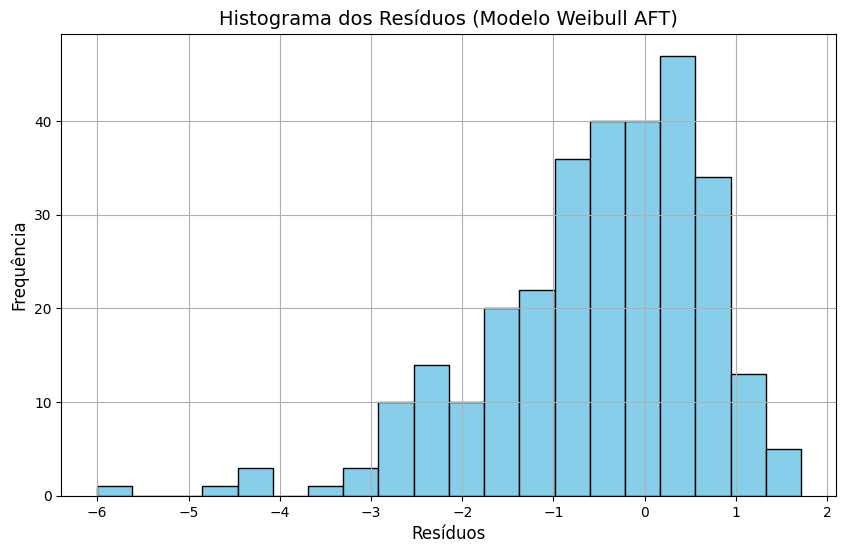

In [ ]:
# Resíduos Baseados no Tempo Ajustado
# Resíduos: diferença entre o log do tempo observado e o log do tempo ajustado
data['log_time_observado'] = np.log(data['time'])
data['log_time_ajustado'] = np.log(aft_model.predict_median(data))
data['residuos'] = data['log_time_observado'] - data['log_time_ajustado']

# Análise Gráfica dos Resíduos

# (a) Histograma dos Resíduos
plt.figure(figsize=(10, 6))
plt.hist(data['residuos'], bins=20, color='skyblue', edgecolor='black')
plt.title("Histograma dos Resíduos (Modelo Weibull AFT)", fontsize=14)
plt.xlabel("Resíduos", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(True)
plt.show()

###Resíduos de Cox-Snell

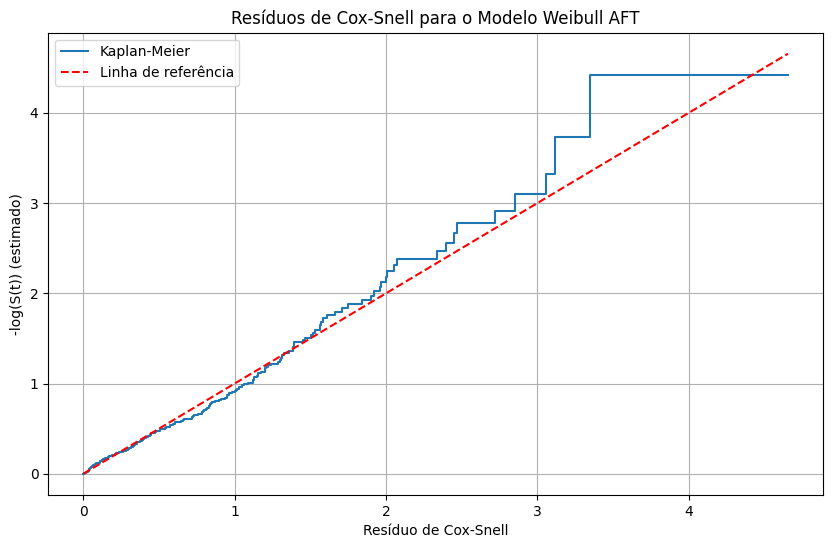

In [ ]:
# (b) Calculando os resíduos de Cox-Snell
# A função de sobrevivência acumulada para Weibull é calculada como S(t) = exp(-lambda * t^rho)
# Onde lambda e rho são parâmetros estimados do modelo

# Calcular a função de risco cumulativo predita para cada indivíduo no tempo observado
data['cox_snell_residuals'] = [
    aft_model.predict_cumulative_hazard(data.iloc[[i]]).loc[data['time'].iloc[i]].values[0]
    for i in range(len(data))
]

# Ajustar um estimador Kaplan-Meier aos resíduos
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(data['cox_snell_residuals'], event_observed=data['event'])

# Plotar os resíduos de Cox-Snell
plt.figure(figsize=(10, 6))
plt.step(kmf.survival_function_.index, -np.log(kmf.survival_function_['KM_estimate']), where="post", label="Kaplan-Meier")
plt.plot([0, max(data['cox_snell_residuals'])], [0, max(data['cox_snell_residuals'])], linestyle='--', color='red', label="Linha de referência")
plt.title("Resíduos de Cox-Snell para o Modelo Weibull AFT")
plt.xlabel("Resíduo de Cox-Snell")
plt.ylabel("-log(S(t)) (estimado)")
plt.legend()
plt.grid()
plt.show()

###Resíduos Deviance

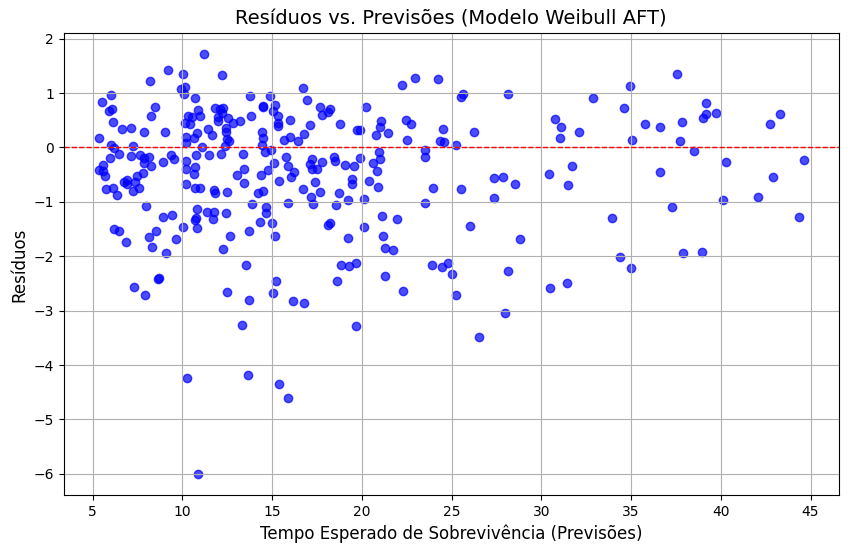

In [ ]:
# (c) Resíduos vs. Previsões
previsoes = aft_model.predict_expectation(data)

plt.figure(figsize=(10, 6))
plt.scatter(previsoes, data['residuos'], alpha=0.7, color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Resíduos vs. Previsões (Modelo Weibull AFT)", fontsize=14)
plt.xlabel("Tempo Esperado de Sobrevivência (Previsões)", fontsize=12)
plt.ylabel("Resíduos", fontsize=12)
plt.grid(True)
plt.show()

###QQ-plot dos resíduos

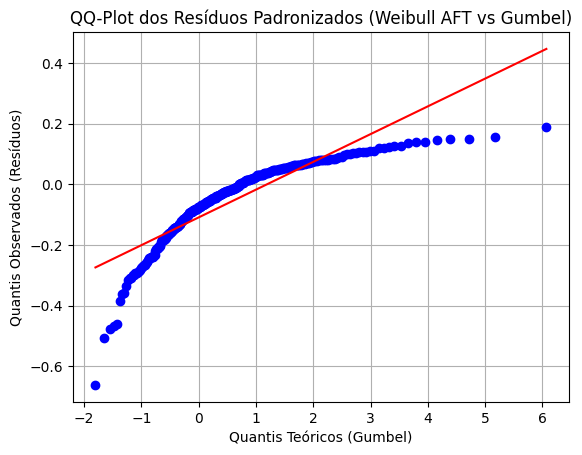

In [ ]:
# (d) QQ-Plot dos Resíduos
import scipy.stats as stats
import matplotlib.pyplot as plt

# Pegar o parâmetro rho_ do modelo
rho = 0.11
sigma = 1 / rho

# Padronizar resíduos
residuos_padronizados = data['residuos'] / sigma

# QQ-plot
stats.probplot(residuos_padronizados, dist="gumbel_r", plot=plt)
plt.title("QQ-Plot dos Resíduos Padronizados (Weibull AFT vs Gumbel)")
plt.xlabel("Quantis Teóricos (Gumbel)")
plt.ylabel("Quantis Observados (Resíduos)")
plt.grid(True)
plt.show()

###Estatística descritiva dos resíduos

In [ ]:
# 4. Estatísticas Descritivas dos Resíduos
print("Estatísticas Descritivas dos Resíduos:")
print(data['residuos'].describe())

Estatísticas Descritivas dos Resíduos:
count    300.000000
mean      -0.512581
std        1.184159
min       -6.006832
25%       -1.187194
50%       -0.314598
75%        0.370995
max        1.714444
Name: residuos, dtype: float64


###Curva de Sobrevivência (Kaplan-Meier vs Modelo Weibull)

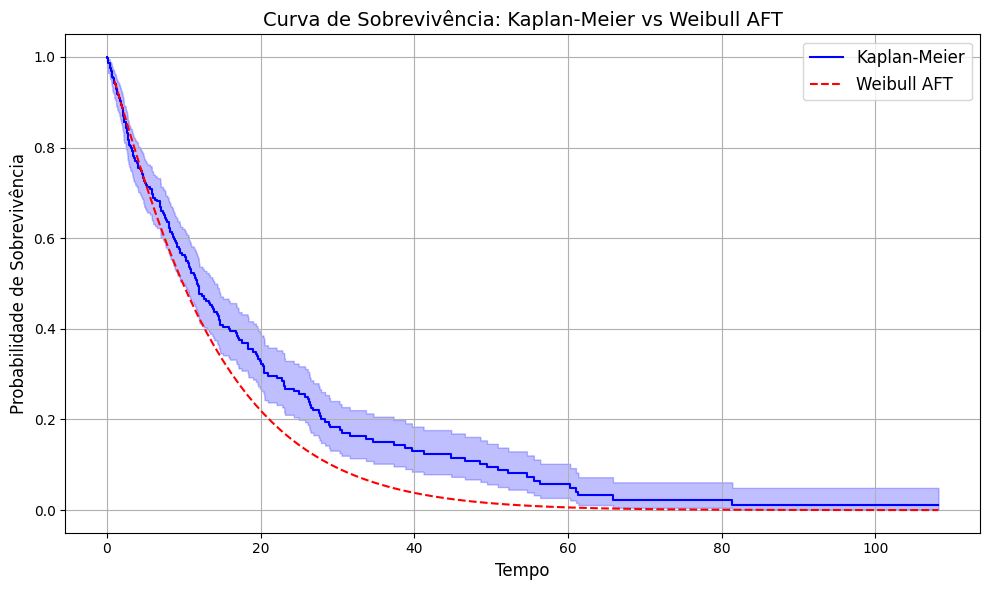

In [ ]:
# 4. Curva de Sobrevivência (Kaplan-Meier vs Modelo Weibull)
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

# Estimativa Kaplan-Meier
kmf.fit(data['time'], event_observed=data['event'], label='Kaplan-Meier')
kmf.plot_survival_function(ci_show=True, ax=plt.gca(), color='blue')


# Previsão do Modelo Weibull
times = np.linspace(1, data['time'].max(), 100)
survival_curve = aft_model.predict_survival_function(data.iloc[0:1], times=times)
plt.plot(times, survival_curve.values.flatten(), label='Weibull AFT', color='red', linestyle='--')

# Configurações do Gráfico
plt.title("Curva de Sobrevivência: Kaplan-Meier vs Weibull AFT", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Probabilidade de Sobrevivência", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

###Gráfico da Curva de Sobrevivência Estimada para Indivíduos selecionados

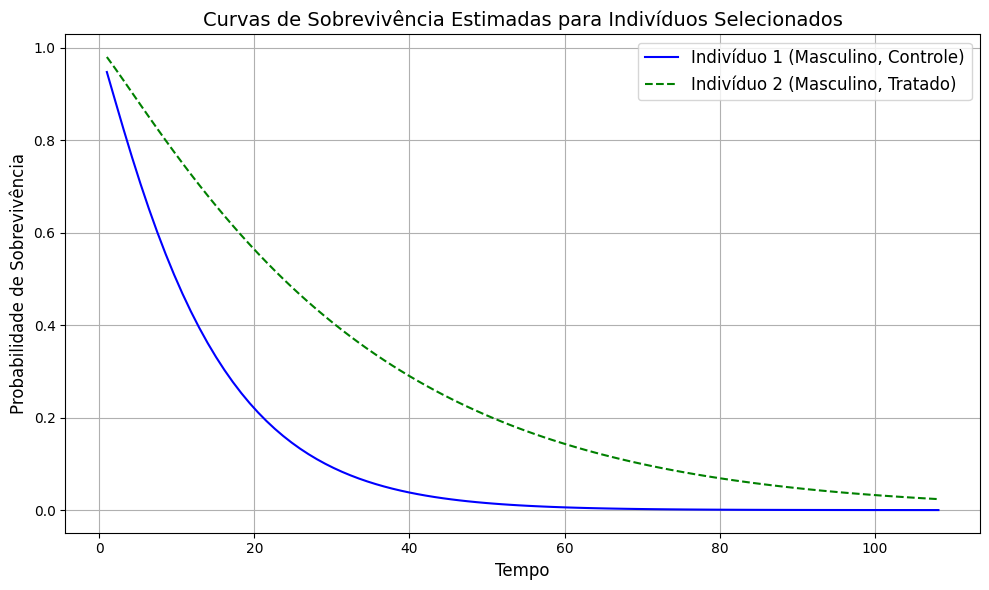

In [ ]:
# 3. Curva de Sobrevivência Estimada para Indivíduos Selecionados

# Selecionando os dois indivíduos com base nas condições fornecidas:
individuo_1 = data[(data['sex'] == 1) & (data['treatment'] == 0)].iloc[0:1]  # Masculino e Controle
individuo_2 = data[(data['sex'] == 1) & (data['treatment'] == 1)].iloc[0:1]  # Masculino e Tratado

# Gerando os tempos para a curva de sobrevivência
times = np.linspace(1, data['time'].max(), 100)

# Prever as curvas de sobrevivência para os indivíduos
survival_curve_1 = aft_model.predict_survival_function(individuo_1, times=times)
survival_curve_2 = aft_model.predict_survival_function(individuo_2, times=times)

# Plotando as curvas de sobrevivência
plt.figure(figsize=(10, 6))
plt.plot(times, survival_curve_1.values.flatten(), label='Indivíduo 1 (Masculino, Controle)', color='blue')
plt.plot(times, survival_curve_2.values.flatten(), label='Indivíduo 2 (Masculino, Tratado)', color='green', linestyle='--')

# Configurações do gráfico
plt.title("Curvas de Sobrevivência Estimadas para Indivíduos Selecionados", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Probabilidade de Sobrevivência", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()

# Exibir o gráfico
plt.show()


###AIC e BIC para o modelo Weibull

In [ ]:
print(aft_model.AIC_)
print (aft_model.BIC_)


1615.5919059469684
1616.9994708962809


#Ajuste do modelo Taxa Acelerada Log Normal

In [ ]:
# Fixar semente para reprodutibilidade
np.random.seed(42)

# Criar dados sintéticos
n = 300  # Número de pacientes
age = np.random.uniform(30, 80, n)  # Idade dos pacientes (30-80 anos)
sex = np.random.choice(['Male', 'Female'], size=n)  # Sexo
treatment = np.random.choice(['Standard', 'Experimental'], size=n)  # Tipo de tratamento

# Mapear variáveis categóricas para numéricas
sex_numeric = (sex == 'Male').astype(int)  # 1 para Male, 0 para Female
treatment_numeric = (treatment == 'Experimental').astype(int)  # 1 para Experimental, 0 para Standard

# Gerar tempos de sobrevivência simulados (em meses)
baseline_hazard = 0.02
survival_time = (-np.log(np.random.uniform(0, 1, n)) /
                 (baseline_hazard * np.exp(0.03 * age - 0.5 * treatment_numeric + 0.2 * sex_numeric)))
survival_time = np.round(survival_time, 2)

# Gerar censura (evento observado ou não)
censoring = np.random.uniform(0.8, 1.5, n) * survival_time
event_observed = (survival_time <= censoring).astype(int)  # 1 para falha, 0 para censurado
observed_time = np.minimum(survival_time, censoring)

# Construir DataFrame
data = pd.DataFrame({
    'age': age,
    'sex': sex_numeric,         # Usando valores numéricos
    'treatment': treatment_numeric,  # Usando valores numéricos
    'time': observed_time,
    'event': event_observed
})

# Visualizar os primeiros dados
print(data.head())

         age  sex  treatment       time  event
0  48.727006    1          0  15.960384      0
1  77.535715    0          1   8.423111      0
2  66.599697    0          1  17.946813      0
3  59.932924    0          0  20.060000      1
4  37.800932    1          0  27.860000      1


In [ ]:
# Ajustar modelos de Taxa Acelerada de Falha
lognormal_aft = LogNormalAFTFitter()
lognormal_aft.fit(data, duration_col='time', event_col='event')

# Resumo do modelo
lognormal_aft.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 300 total observations, 86 right-censored observations>
             duration col = 'time'
                event col = 'event'
   number of observations = 300
number of events observed = 214
           log-likelihood = -827.53
         time fit was run = 2025-08-25 18:40:36 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                  
mu_    age       -0.02      0.98      0.01           -0.04           -0.01                0.97                0.99
       sex       -0.16      0.85      0.16           -0.48            0.16                0.62                1.17
       treatment  0.61      1.85      0.16            0.29            0.93                1.34                2.54
       Intercept  3.45     31.36      0.33            2.79            4.10               16.29               60.39
sigma_ Intercept  0.27      1.31      0.05            0.18            0.37                1.19                1.44

                  cmp to     z      p  -log2(p)
param  covariate                               
mu_    age          0.00 -4.47 <0.005     16.99
       sex          0.00 -0.99   0.32      1.63
       treatment    0.00  3.77 <0.005     12.60
       Intercept    0.00 10.31 <0.005     80.34
sigma_ Intercept    0.00  5.58 <0.005     25.34
---
Concordance = 0.63
AIC = 1665.07
log-likelihood ratio test = 33.48 on 3 df
-log2(p) of ll-ratio test = 21.90

###Análise de Resíduos

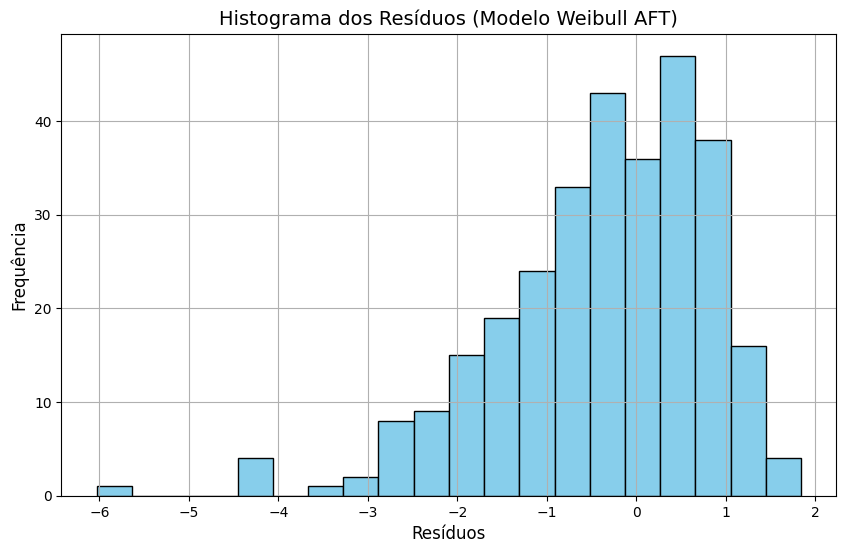

In [ ]:
# 2. Resíduos Baseados no Tempo Ajustado
# Resíduos: diferença entre o log do tempo observado e o log do tempo ajustado
data['log_time_observado'] = np.log(data['time'])
data['log_time_ajustado'] = np.log(lognormal_aft.predict_median(data))
data['residuos'] = data['log_time_observado'] - data['log_time_ajustado']

# 3. Análise Gráfica dos Resíduos

# (a) Histograma dos Resíduos
plt.figure(figsize=(10, 6))
plt.hist(data['residuos'], bins=20, color='skyblue', edgecolor='black')
plt.title("Histograma dos Resíduos (Modelo Weibull AFT)", fontsize=14)
plt.xlabel("Resíduos", fontsize=12)
plt.ylabel("Frequência", fontsize=12)
plt.grid(True)
plt.show()

###Residuo de Cox-snell

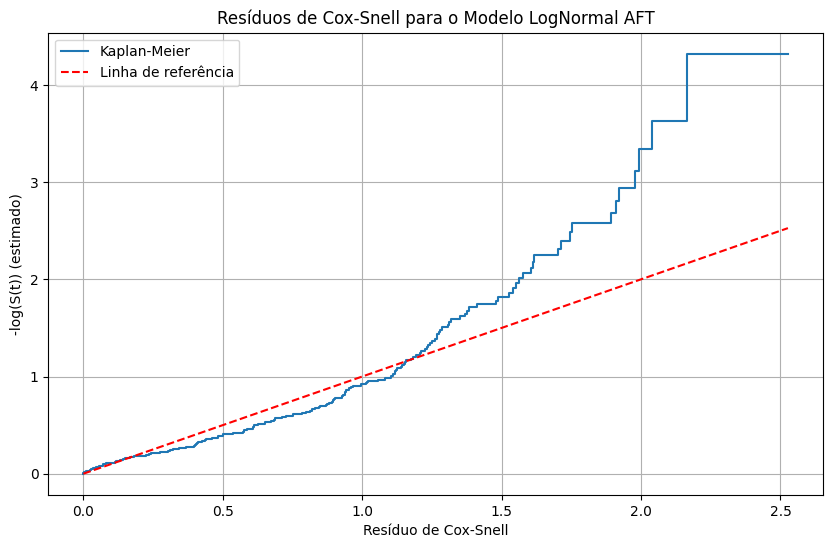

In [ ]:
# Calcular a função de risco cumulativo predita para cada indivíduo no tempo observado
data['cox_snell_residuals'] = [
    lognormal_aft.predict_cumulative_hazard(data.iloc[[i]]).loc[data['time'].iloc[i]].values[0]
    for i in range(len(data))
]

# Ajustar um estimador Kaplan-Meier aos resíduos
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(data['cox_snell_residuals'], event_observed=data['event'])

# Plotar os resíduos de Cox-Snell
plt.figure(figsize=(10, 6))
plt.step(kmf.survival_function_.index, -np.log(kmf.survival_function_['KM_estimate']), where="post", label="Kaplan-Meier")
plt.plot([0, max(data['cox_snell_residuals'])], [0, max(data['cox_snell_residuals'])], linestyle='--', color='red', label="Linha de referência")
plt.title("Resíduos de Cox-Snell para o Modelo LogNormal AFT")
plt.xlabel("Resíduo de Cox-Snell")
plt.ylabel("-log(S(t)) (estimado)")
plt.legend()
plt.grid()
plt.show()

###Resíduos vs. Previsões

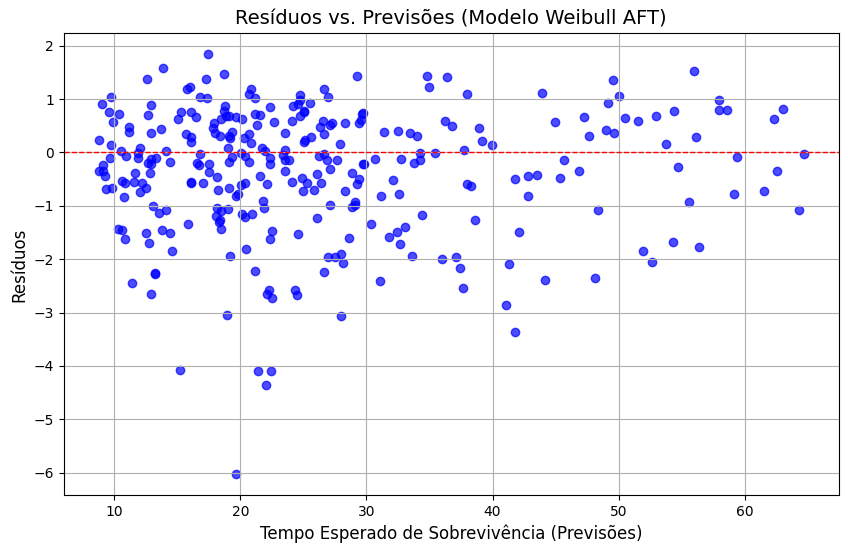

In [ ]:
# (b) Resíduos vs. Previsões
previsoes = lognormal_aft.predict_expectation(data)

plt.figure(figsize=(10, 6))
plt.scatter(previsoes, data['residuos'], alpha=0.7, color='blue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Resíduos vs. Previsões (Modelo Log-Normal AFT)", fontsize=14)
plt.xlabel("Tempo Esperado de Sobrevivência (Previsões)", fontsize=12)
plt.ylabel("Resíduos", fontsize=12)
plt.grid(True)
plt.show()

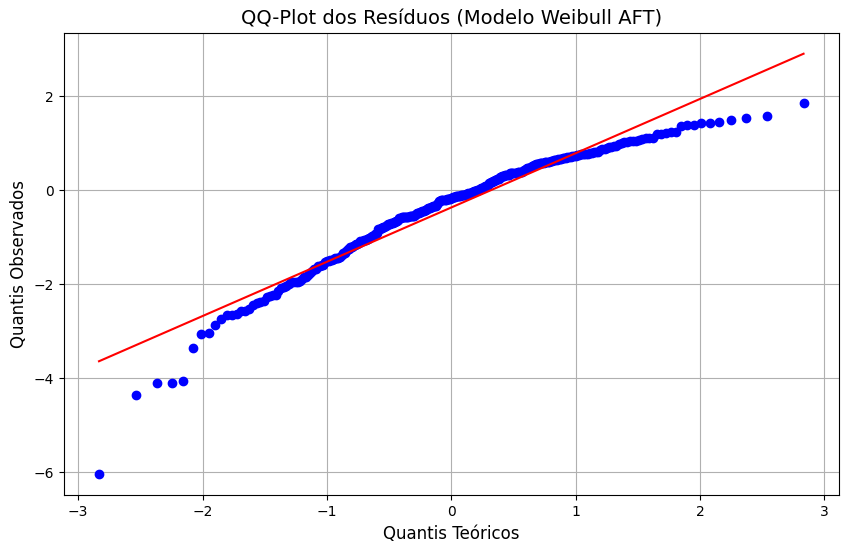

In [ ]:
# (c) QQ-Plot dos Resíduos
import scipy.stats as stats

plt.figure(figsize=(10, 6))
stats.probplot(data['residuos'], dist="norm", plot=plt)
plt.title("QQ-Plot dos Resíduos (Modelo Log-Normal AFT)", fontsize=14)
plt.xlabel("Quantis Teóricos", fontsize=12)
plt.ylabel("Quantis Observados", fontsize=12)
plt.grid(True)
plt.show()

###Estatística descritiva dos resíduos

In [ ]:
# 4. Estatísticas Descritivas dos Resíduos
print("Estatísticas Descritivas dos Resíduos:")
print(data['residuos'].describe())

Estatísticas Descritivas dos Resíduos:
count    300.000000
mean      -0.375295
std        1.181901
min       -6.031770
25%       -1.041016
50%       -0.180721
75%        0.528689
max        1.842097
Name: residuos, dtype: float64


###Gráfico da curva de sobrevivência estimada

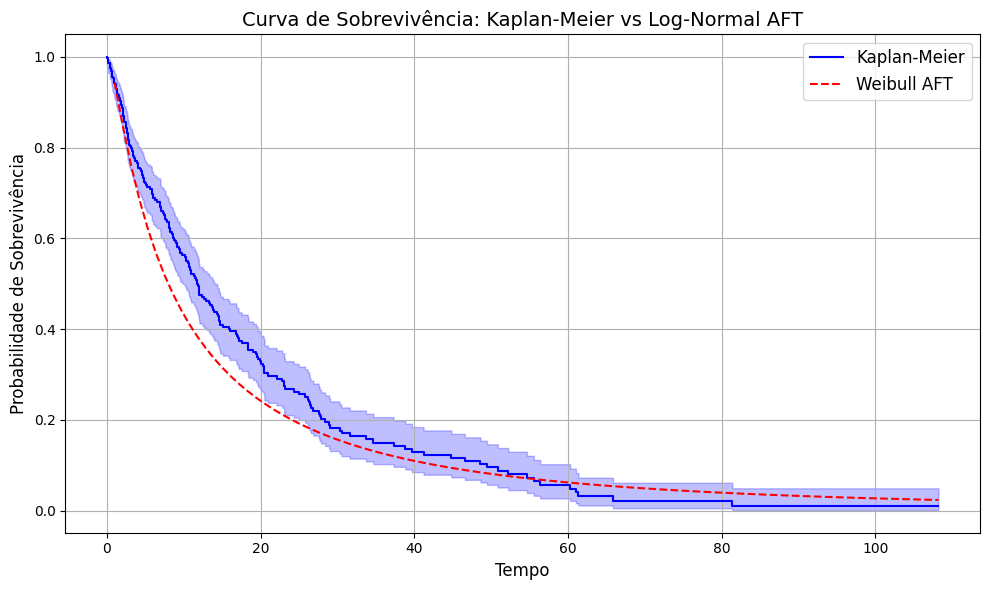

In [ ]:
# 4. Curva de Sobrevivência (Kaplan-Meier vs Modelo Log-Normal)
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

# Estimativa Kaplan-Meier
kmf.fit(data['time'], event_observed=data['event'], label='Kaplan-Meier')
kmf.plot_survival_function(ci_show=True, ax=plt.gca(), color='blue')


# Previsão do Modelo Lognormal
times = np.linspace(1, data['time'].max(), 100)
survival_curve = lognormal_aft.predict_survival_function(data.iloc[0:1], times=times)
plt.plot(times, survival_curve.values.flatten(), label='Weibull AFT', color='red', linestyle='--')

# Configurações do Gráfico
plt.title("Curva de Sobrevivência: Kaplan-Meier vs Log-Normal AFT", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Probabilidade de Sobrevivência", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

###Gráfico da Curva de Sobrevivência Estimada para Indivíduos selecionados

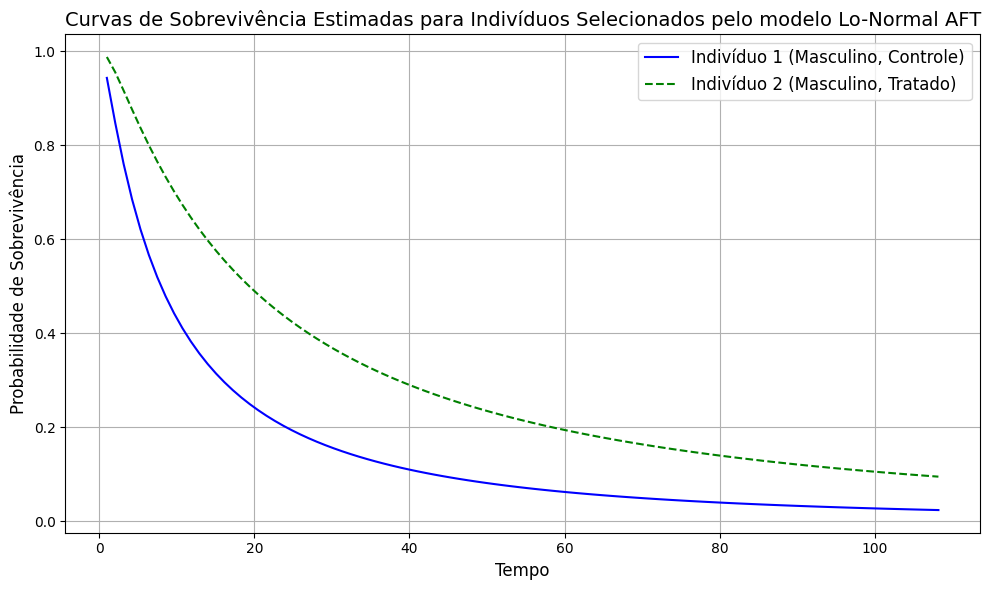

In [ ]:
# 3. Curva de Sobrevivência Estimada para Indivíduos Selecionados

# Selecionando os dois indivíduos com base nas condições fornecidas:
individuo_1 = data[(data['sex'] == 1) & (data['treatment'] == 0)].iloc[0:1]  # Masculino e Controle
individuo_2 = data[(data['sex'] == 1) & (data['treatment'] == 1)].iloc[0:1]  # Masculino e Tratado

# Gerando os tempos para a curva de sobrevivência
times = np.linspace(1, data['time'].max(), 100)

# Prever as curvas de sobrevivência para os indivíduos
survival_curve_1 = lognormal_aft.predict_survival_function(individuo_1, times=times)
survival_curve_2 = lognormal_aft.predict_survival_function(individuo_2, times=times)

# Plotando as curvas de sobrevivência
plt.figure(figsize=(10, 6))
plt.plot(times, survival_curve_1.values.flatten(), label='Indivíduo 1 (Masculino, Controle)', color='blue')
plt.plot(times, survival_curve_2.values.flatten(), label='Indivíduo 2 (Masculino, Tratado)', color='green', linestyle='--')

# Configurações do gráfico
plt.title("Curvas de Sobrevivência Estimadas para Indivíduos Selecionados pelo modelo Lo-Normal AFT", fontsize=14)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Probabilidade de Sobrevivência", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()

# Exibir o gráfico
plt.show()


###AIC e BIC para o modelo Lo-normal

In [ ]:
print(lognormal_aft.AIC_)
print (lognormal_aft.BIC_)

1665.0674414432356
1666.475006392548
